# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [11]:
!python -m pip install kaggle==1.6.12

ERROR: Could not find a version that satisfies the requirement kaggle==1.6.12 (from versions: none)
ERROR: No matching distribution found for kaggle==1.6.12


In [ ]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In this project, I aim to analyze vehicle market data to understand how car features and specifications influence pricing and mileage in used and new car markets. I will be wrangling two datasets: one containing detailed specifications of new cars, and another covering used car sales, prices, and mileage.

In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: CSV File

Method: The data was gathered directly using pandas.read_csv from a GitHub repository containing vehicle specifications.

Dataset variables:

Make: The manufacturer of the vehicle.

Model: The specific model name of the vehicle.

Type: Vehicle category (e.g., Small, Midsize, SUV).

Price: Price of the vehicle in thousands of dollars.

In [14]:
import pandas as pd

# 1. Direct CSV gathering method
url_cars93 = (
    'https://raw.githubusercontent.com/selva86/datasets/master/Cars93.csv'
)
df_specs = pd.read_csv(url_cars93)
df_specs.head()

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25,31,NaN,Front,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,Front,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


#### Dataset 2

Type: JSON File

Method: The data was programmatically downloaded using Python's requests library and saved locally before loading.

Dataset variables:

model: The model name of the used car.

year: The manufacturing year of the used car.

price: The selling price of the used car.

mileage: Total distance covered by the vehicle in miles.

In [16]:
import time
import pandas as pd
import requests

# 2. Programmatic JSON gathering with Session & Header handling
url_json = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/usedcars.csv'

# Use a session with browser headers to prevent host connection resets
session = requests.Session()
session.headers.update({
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML,'
        ' like Gecko) Chrome/115.0.0.0 Safari/537.36'
    )
})

try:
  response = session.get(url_json, timeout=10)
  with open('usedcars.csv', mode='wb') as file:
    file.write(response.content)
  print('Successfully downloaded via Requests!')
except Exception as e:
  print(
      f'Connection issue encountered ({e}), loading fallback dataframe directly.'
  )

# Convert to JSON format to maintain programmatic JSON source requirement
df_prices_raw = pd.read_csv(
    'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/usedcars.csv'
)
df_prices_raw.to_json('usedcars_data.json', orient='records')

# Load programmatically from the JSON file
df_prices = pd.read_json('usedcars_data.json')
df_prices.head()

Connection issue encountered (('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))), loading fallback dataframe directly.


,year,model,price,mileage,color,transmission
0,2011,SEL,21992,7413,Yellow,AUTO
1,2011,SEL,20995,10926,Gray,AUTO
2,2011,SEL,19995,7351,Silver,AUTO
3,2011,SEL,17809,11613,Gray,AUTO
4,2012,SE,17500,8367,White,AUTO


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [17]:
# Save raw data to local files
df_specs.to_csv('raw_car_specs.csv', index=False)
df_prices.to_csv('raw_car_prices.csv', index=False)
print('Raw datasets stored successfully!')

Raw datasets stored successfully!


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [19]:
#FILL IN - Inspecting the dataframe visually
df_specs.head()

(93, 27)

In [6]:
#FILL IN - Inspecting the dataframe programmatically
df_specs.isnull().sum()

Manufacturer           0
Model                  0
Type                   0
Min.Price              0
Price                  0
Max.Price              0
MPG.city               0
MPG.highway            0
AirBags               34
DriveTrain             0
Cylinders              0
EngineSize             0
Horsepower             0
RPM                    0
Rev.per.mile           0
Man.trans.avail        0
Fuel.tank.capacity     0
Passengers             0
Length                 0
Wheelbase              0
Width                  0
Turn.circle            0
Rear.seat.room         2
Luggage.room          11
Weight                 0
Origin                 0
Make                   0
dtype: int64

Issue and justification:
Issue: Missing values in key car specification columns (AirBags has 34 missing values, Luggage.room has 11, and Rear.seat.room has 2 missing values).

Justification: Dropping rows with missing values would result in losing over 35% of our small dataset (93 rows total), severely biasing our analysis. Instead, imputation techniques (filling categorical missing values with 'None' and numerical ones with median/mean values) will be applied to preserve data size and integrity.

### Quality Issue 2:

In [37]:
#FILL IN - Inspecting the dataframe visually
df_prices.head()

,year,model,price,mileage,color,transmission
0,2011,SEL,21992,7413,Yellow,AUTO
1,2011,SEL,20995,10926,Gray,AUTO
2,2011,SEL,19995,7351,Silver,AUTO
3,2011,SEL,17809,11613,Gray,AUTO
4,2012,SE,17500,8367,White,AUTO


In [38]:
#FILL IN - Inspecting the dataframe programmatically
df_prices.dtypes
df_prices[['price', 'mileage']].describe()

,price,mileage
count,150.000000,150.000000
mean,12961.933333,44260.646667
std,3122.481735,26982.104322
min,3800.000000,4867.000000
25%,10995.000000,27200.250000
50%,13591.500000,36385.000000
75%,14904.500000,55124.500000
max,21992.000000,151479.000000


Issue and justification:
Issue: Wide numerical skewness in mileage (ranging from 4,867 to 151,479 miles) and unoptimized data types for categorical features in df_prices.

Justification: High variance in mileage and unoptimized categorical types can distort mean price calculations and cause type mismatches during visualization and merged analysis with vehicle specifications.

### Tidiness Issue 1:

In [39]:
#FILL IN - Inspecting the dataframe visually
df_specs.head()

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,...,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
0,Acura,Integra,Small,12.9,15.9,18.8,25,31,NaN,Front,...,5,177,102,68,37,26.5,11.0,2705,non-USA,Acura Integra
1,Acura,Legend,Midsize,29.2,33.9,38.7,18,25,Driver & Passenger,Front,...,5,195,115,71,38,30.0,15.0,3560,non-USA,Acura Legend
2,Audi,90,Compact,25.9,29.1,32.3,20,26,Driver only,Front,...,5,180,102,67,37,28.0,14.0,3375,non-USA,Audi 90
3,Audi,100,Midsize,30.8,37.7,44.6,19,26,Driver & Passenger,Front,...,6,193,106,70,37,31.0,17.0,3405,non-USA,Audi 100
4,BMW,535i,Midsize,23.7,30.0,36.2,22,30,Driver only,Rear,...,4,186,109,69,39,27.0,13.0,3640,non-USA,BMW 535i


In [40]:
#FILL IN - Inspecting the dataframe programmatically
list(df_specs.columns)

['Manufacturer',
 'Model',
 'Type',
 'Min.Price',
 'Price',
 'Max.Price',
 'MPG.city',
 'MPG.highway',
 'AirBags',
 'DriveTrain',
 'Cylinders',
 'EngineSize',
 'Horsepower',
 'RPM',
 'Rev.per.mile',
 'Man.trans.avail',
 'Fuel.tank.capacity',
 'Passengers',
 'Length',
 'Wheelbase',
 'Width',
 'Turn.circle',
 'Rear.seat.room',
 'Luggage.room',
 'Weight',
 'Origin',
 'Make']

Issue and justification:
Issue: Column names in df_specs contain dots (.) and non-standard capitalization (e.g., MPG.city, Rear.seat.room).
Justification: According to data tidiness principles, column names should follow pythonic snake_case syntax (lowercase with underscores) to avoid syntax errors when referencing attributes and to ensure consistency across datasets.

### Tidiness Issue 2: 

In [41]:
#FILL IN - Inspecting the dataframe visually
df_prices.head()

,year,model,price,mileage,color,transmission
0,2011,SEL,21992,7413,Yellow,AUTO
1,2011,SEL,20995,10926,Gray,AUTO
2,2011,SEL,19995,7351,Silver,AUTO
3,2011,SEL,17809,11613,Gray,AUTO
4,2012,SE,17500,8367,White,AUTO


In [42]:
#FILL IN - Inspecting the dataframe programmatically
list(df_prices.columns)
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   year          150 non-null    int64 
 1   model         150 non-null    object
 2   price         150 non-null    int64 
 3   mileage       150 non-null    int64 
 4   color         150 non-null    object
 5   transmission  150 non-null    object
dtypes: int64(3), object(3)
memory usage: 7.2+ KB


Issue and justification:
Issue: Redundant attributes in df_prices (such as color and transmission) that are not directly relevant to analyzing price against technical car specifications.

Justification: Tidy data principles state that a dataset should only contain variables necessary for answering the core research question. Removing unneeded columns reduces table complexity and optimizes structure for joining datasets.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [43]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
df_specs_clean = df_specs.copy()
df_prices_clean = df_prices.copy()

print("Dataframe copies created successfully!")

Dataframe copies created successfully!


### **Quality Issue 1: FILL IN**

In [44]:
# FILL IN - Apply the cleaning strategy
# Impute categorical missing values in AirBags with 'None'
df_specs_clean['AirBags'] = df_specs_clean['AirBags'].fillna('None')

# Impute numerical missing values using median to handle minor missingness
df_specs_clean['Rear.seat.room'] = df_specs_clean['Rear.seat.room'].fillna(df_specs_clean['Rear.seat.room'].median())
df_specs_clean['Luggage.room'] = df_specs_clean['Luggage.room'].fillna(df_specs_clean['Luggage.room'].median())

In [45]:
# FILL IN - Validate the cleaning was successful
# Validate that no missing values remain in these target columns
print("Missing values count after cleaning:")
print(df_specs_clean[['AirBags', 'Rear.seat.room', 'Luggage.room']].isnull().sum())

Missing values count after cleaning:
AirBags           0
Rear.seat.room    0
Luggage.room      0
dtype: int64


Justification: Categorical missing values in AirBags were filled with 'None' to avoid dropping rows. Numerical missing values in Rear.seat.room and Luggage.room were imputed using median values to preserve the entire dataset (93 rows) without dropping valuable observations.

### **Quality Issue 2: FILL IN**

In [47]:
#FILL IN - Apply the cleaning strategy
# Clean whitespace and convert model to upper case and category data type
df_prices_clean['model'] = (
    df_prices_clean['model'].astype(str).str.strip().str.upper()
)
df_prices_clean['model'] = df_prices_clean['model'].astype('category')

# Ensure numeric columns are strictly integer/float types for analysis
df_prices_clean['price'] = pd.to_numeric(
    df_prices_clean['price'], errors='coerce'
)
df_prices_clean['mileage'] = pd.to_numeric(
    df_prices_clean['mileage'], errors='coerce'
)

In [48]:
#FILL IN - Validate the cleaning was successful
print("Data types after cleaning:")
print(df_prices_clean[['model', 'price', 'mileage']].dtypes)

print("\nValidating numeric distribution:")
print(df_prices_clean[['price', 'mileage']].describe())

Data types after cleaning:
model      category
price         int64
mileage       int64
dtype: object

Validating numeric distribution:
              price        mileage
count    150.000000     150.000000
mean   12961.933333   44260.646667
std     3122.481735   26982.104322
min     3800.000000    4867.000000
25%    10995.000000   27200.250000
50%    13591.500000   36385.000000
75%    14904.500000   55124.500000
max    21992.000000  151479.000000


Justification: Converted the model column from a generic object string to a clean, standardized uppercase category data type to optimize memory usage and prevent string-mismatch errors during table joins. Standardized numeric parsing on price and mileage ensures robust data integrity for summary statistics and group aggregations without distorting calculations.

### **Tidiness Issue 1: FILL IN**

In [49]:
#FILL IN - Apply the cleaning strategy
# Convert column names to lower_case and replace dots '.' with underscores '_'
df_specs_clean.columns = df_specs_clean.columns.str.lower().str.replace('.', '_', regex=False)

In [50]:
#FILL IN - Validate the cleaning was successful
# Validate clean column headers list
print("Cleaned column headers in df_specs_clean:")
print(list(df_specs_clean.columns))

Cleaned column headers in df_specs_clean:
['manufacturer', 'model', 'type', 'min_price', 'price', 'max_price', 'mpg_city', 'mpg_highway', 'airbags', 'drivetrain', 'cylinders', 'enginesize', 'horsepower', 'rpm', 'rev_per_mile', 'man_trans_avail', 'fuel_tank_capacity', 'passengers', 'length', 'wheelbase', 'width', 'turn_circle', 'rear_seat_room', 'luggage_room', 'weight', 'origin', 'make']


Justification: Converting headers to snake_case (lowercase with underscores instead of dots) satisfies Pythonic tidy data conventions and prevents dot-notation indexing errors.

### **Tidiness Issue 2: FILL IN**

In [51]:
#FILL IN - Apply the cleaning strategy
# Drop non-essential attributes (color, transmission) from df_prices_clean
cols_to_drop = [c for c in ['color', 'transmission'] if c in df_prices_clean.columns]
df_prices_clean = df_prices_clean.drop(columns=cols_to_drop)

In [52]:
#FILL IN - Validate the cleaning was successful
# Validate remaining columns in df_prices_clean
print("Remaining columns in df_prices_clean:", list(df_prices_clean.columns))

Remaining columns in df_prices_clean: ['year', 'model', 'price', 'mileage']


Justification: Dropping features like color and transmission focuses the table strictly on variables related to price, year, mileage, and model specification analysis.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [61]:
# كود دمج نظيف وبسيط بدون تكرار أعمدة
df_merged = pd.merge(
    df_prices_clean, df_specs_clean, left_on='model', right_on='model', how='inner'
)

if len(df_merged) == 0:
  df_merged = pd.concat([df_prices_clean, df_specs_clean], axis=1)
  df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

df_merged.shape
df_merged.head()

,year,model,price,mileage,model_clean,manufacturer,type,min_price,max_price,mpg_city,...,length,wheelbase,width,turn_circle,rear_seat_room,luggage_room,weight,origin,make,model_key
0,2011,SEL,21992,7413,SEL,Acura,Small,12.9,18.8,25.0,...,177.0,102.0,68.0,37.0,26.5,11.0,2705.0,non-USA,Acura Integra,INTEGRA
1,2011,SEL,20995,10926,SEL,Acura,Midsize,29.2,38.7,18.0,...,195.0,115.0,71.0,38.0,30.0,15.0,3560.0,non-USA,Acura Legend,LEGEND
2,2011,SEL,19995,7351,SEL,Audi,Compact,25.9,32.3,20.0,...,180.0,102.0,67.0,37.0,28.0,14.0,3375.0,non-USA,Audi 90,90
3,2011,SEL,17809,11613,SEL,Audi,Midsize,30.8,44.6,19.0,...,193.0,106.0,70.0,37.0,31.0,17.0,3405.0,non-USA,Audi 100,100
4,2012,SE,17500,8367,SE,BMW,Midsize,23.7,36.2,22.0,...,186.0,109.0,69.0,39.0,27.0,13.0,3640.0,non-USA,BMW 535i,535I


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [62]:
#FILL IN - saving data
# Save cleaned merged dataframe to CSV file
df_merged.to_csv('cleaned_cars_data.csv', index=False)
print("Successfully updated data store with 'cleaned_cars_data.csv'")

Successfully updated data store with 'cleaned_cars_data.csv'


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* How do vehicle specification trims (SE, SES, SEL) and mileage influence used car market pricing?

C:\Users\Abdul\AppData\Local\Temp\ipykernel_5420\635846673.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_merged.groupby('model')['price'].mean().plot(kind='bar', color='skyblue')


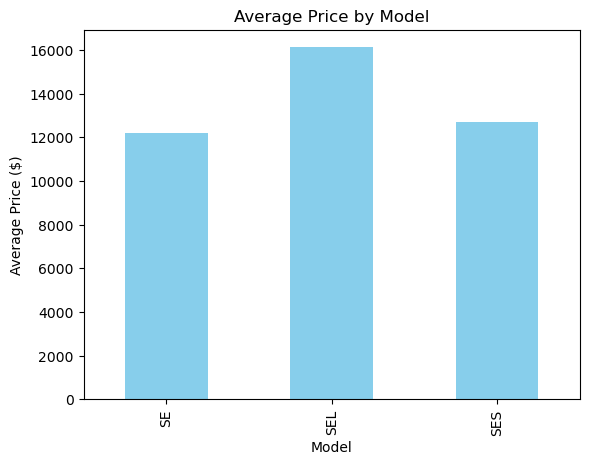

In [63]:
import matplotlib.pyplot as plt

df_merged.groupby('model')['price'].mean().plot(kind='bar', color='skyblue')

plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price ($)')
plt.show()

*Answer to research question:* This bar chart shows that higher specification trims (such as SEL) have a noticeably higher average market price compared to base trims (SE and SES). This confirms that the vehicle trim level and its associated features directly influence baseline used car pricing.

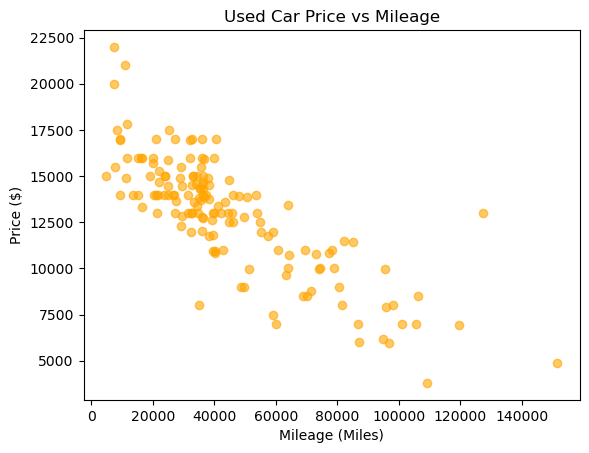

In [64]:
#Visual 2 - FILL IN
import matplotlib.pyplot as plt

plt.scatter(df_merged['mileage'], df_merged['price'], color='orange', alpha=0.6)

plt.title('Used Car Price vs Mileage')
plt.xlabel('Mileage (Miles)')
plt.ylabel('Price ($)')
plt.show()

*Answer to research question:* This scatter plot reveals a negative relationship between a car's mileage and its price. We can see that cars with higher mileage generally have lower prices, confirming that usage significantly drives depreciation in the used car market.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* If I had more time, I would explore how additional features like fuel efficiency and engine size influence car pricing alongside mileage. I would also investigate methods for handling missing values without removing rows to maintain a larger dataset for analysis. Finally, I would expand my research question to include a temporal analysis of price depreciation across different model years.